<a href="https://colab.research.google.com/github/hirishikesh/uk-road-safety-eda/blob/main/notebooks/uk_road_safety_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UK Road Safety EDA (2020–2024)
**Author:** Hirishikesh Parthasarathy | MSc AI, University of Edinburgh  
**Data Source:** UK Department for Transport — GOV.UK  
**Business Question:** What factors most strongly predict road accident severity in Great Britain?

In [1]:
# Downloading the official UK road safety data from GOV.UK
!wget -q -O collisions.csv "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-last-5-years.csv"
!wget -q -O vehicles.csv "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-vehicle-last-5-years.csv"
!wget -q -O casualties.csv "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-casualty-last-5-years.csv"
print(" All files have been downloaded")

 All files have been downloaded


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
print("Libraries loaded")

Libraries loaded


In [3]:
# Load all three tables
collisions = pd.read_csv('collisions.csv', low_memory=False)
vehicles = pd.read_csv('vehicles.csv', low_memory=False)
casualties = pd.read_csv('casualties.csv', low_memory=False)

print(f"Collisions: {collisions.shape}")
print(f"Vehicles:   {vehicles.shape}")
print(f"Casualties: {casualties.shape}")

Collisions: (503475, 44)
Vehicles:   (920692, 32)
Casualties: (640522, 23)


In [4]:
# Quick overview of collisions table
print("=== COLLISIONS ===")
print(collisions.dtypes.value_counts())
print(f"\nNull % per column (top 10):")
print((collisions.isnull().mean() * 100).sort_values(ascending=False).head(10).round(2))

=== COLLISIONS ===
int64      30
object      8
float64     6
Name: count, dtype: int64

Null % per column (top 10):
local_authority_highway_current    0.02
location_easting_osgr              0.01
longitude                          0.01
latitude                           0.01
location_northing_osgr             0.01
collision_ref_no                   0.00
collision_index                    0.00
collision_year                     0.00
collision_severity                 0.00
number_of_vehicles                 0.00
dtype: float64


In [6]:
# Check actual column names
print(collisions.columns.tolist())

['collision_index', 'collision_year', 'collision_ref_no', 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'police_force', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week', 'time', 'local_authority_district', 'local_authority_ons_district', 'local_authority_highway', 'local_authority_highway_current', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail_historic', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards_historic', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'lsoa_of_accident_location', 'enhanced_severity_collision', 'collision_injury_based', 

In [7]:
# Correct column name is collision_severity
print("Collision Severity distribution:")
print(collisions['collision_severity'].value_counts())
print("\nValue counts %:")
print((collisions['collision_severity'].value_counts(normalize=True) * 100).round(2))

Collision Severity distribution:
collision_severity
3    386007
2    109977
1      7491
Name: count, dtype: int64

Value counts %:
collision_severity
3    76.67
2    21.84
1     1.49
Name: proportion, dtype: float64


In [8]:
# Check casualties columns too before merging
print(casualties.columns.tolist())

['collision_index', 'collision_year', 'collision_ref_no', 'vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'age_band_of_casualty', 'casualty_severity', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_imd_decile', 'lsoa_of_casualty', 'enhanced_casualty_severity', 'casualty_injury_based', 'casualty_adjusted_severity_serious', 'casualty_adjusted_severity_slight', 'casualty_distance_banding']


In [9]:
# Check vehicles columns too before merging
print(vehicles.columns.tolist())

['collision_index', 'collision_year', 'collision_ref_no', 'vehicle_reference', 'vehicle_type', 'towing_and_articulation', 'vehicle_manoeuvre_historic', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane_historic', 'vehicle_location_restricted_lane', 'junction_location', 'skidding_and_overturning', 'hit_object_in_carriageway', 'vehicle_leaving_carriageway', 'hit_object_off_carriageway', 'first_point_of_impact', 'vehicle_left_hand_drive', 'journey_purpose_of_driver_historic', 'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver', 'age_band_of_driver', 'engine_capacity_cc', 'propulsion_code', 'age_of_vehicle', 'generic_make_model', 'driver_imd_decile', 'lsoa_of_driver', 'escooter_flag', 'driver_distance_banding']


In [10]:
# Merge collisions + casualties on collision_index
df = collisions.merge(casualties, on='collision_index', how='left',
                      suffixes=('', '_cas'))

print(f"Merged shape: {df.shape}")
print(f"Severity distribution after merge:")
print(df['collision_severity'].value_counts())

Merged shape: (640522, 66)
Severity distribution after merge:
collision_severity
3    479102
2    149030
1     12390
Name: count, dtype: int64


In [12]:
# Create a clean severity label for plotting
severity_map = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
df['severity_label'] = df['collision_severity'].map(severity_map)

# Parse date and extract time features
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['hour'] = df['date_cas'] if 'time' not in df.columns else pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.hour

print(" Date features extracted")
print(df[['date', 'year', 'month', 'collision_severity', 'severity_label']].head())

 Date features extracted
        date  year  month  collision_severity severity_label
0 2021-05-22  2021      5                   3         Slight
1 2021-05-22  2021      5                   3         Slight
2 2021-10-20  2021     10                   3         Slight
3 2020-12-01  2020     12                   3         Slight
4 2021-12-09  2021     12                   3         Slight


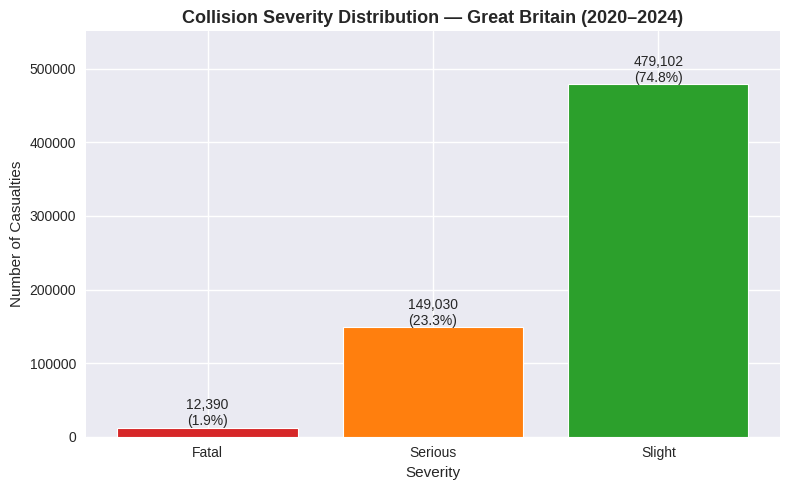

In [13]:
# ── PLOT 1: Severity Distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
severity_counts = df['severity_label'].value_counts().reindex(['Fatal', 'Serious', 'Slight'])
colours = ['#d62728', '#ff7f0e', '#2ca02c']
bars = ax.bar(severity_counts.index, severity_counts.values, color=colours, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, severity_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Collision Severity Distribution — Great Britain (2020–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Severity')
ax.set_ylabel('Number of Casualties')
ax.set_ylim(0, severity_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('plot1_severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

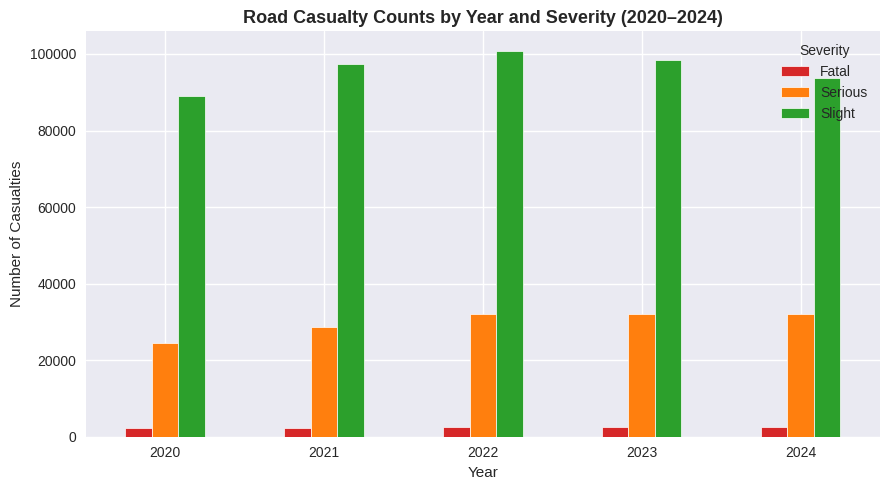

In [14]:
# ── PLOT 2: Accidents by Year ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
yearly = df.groupby(['year', 'severity_label']).size().unstack(fill_value=0)
yearly = yearly.reindex(columns=['Fatal', 'Serious', 'Slight'])
yearly.plot(kind='bar', ax=ax, color=['#d62728', '#ff7f0e', '#2ca02c'],
            edgecolor='white', linewidth=0.5)
ax.set_title('Road Casualty Counts by Year and Severity (2020–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Casualties')
ax.legend(title='Severity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('plot2_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

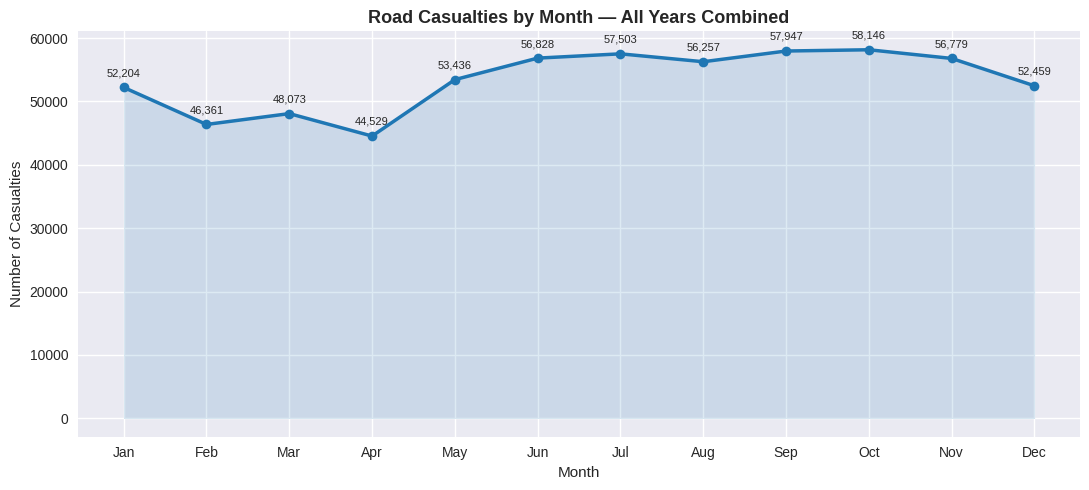

In [15]:
# ── PLOT 3: Accidents by Month ───────────────────────────────────────────────
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month_name').size().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(month_order, monthly.values, marker='o', linewidth=2.5,
        color='#1f77b4', markersize=7)
ax.fill_between(month_order, monthly.values, alpha=0.15, color='#1f77b4')
for i, (m, v) in enumerate(zip(month_order, monthly.values)):
    ax.annotate(f'{v:,}', (m, v), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8)
ax.set_title('Road Casualties by Month — All Years Combined', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Casualties')
plt.tight_layout()
plt.savefig('plot3_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

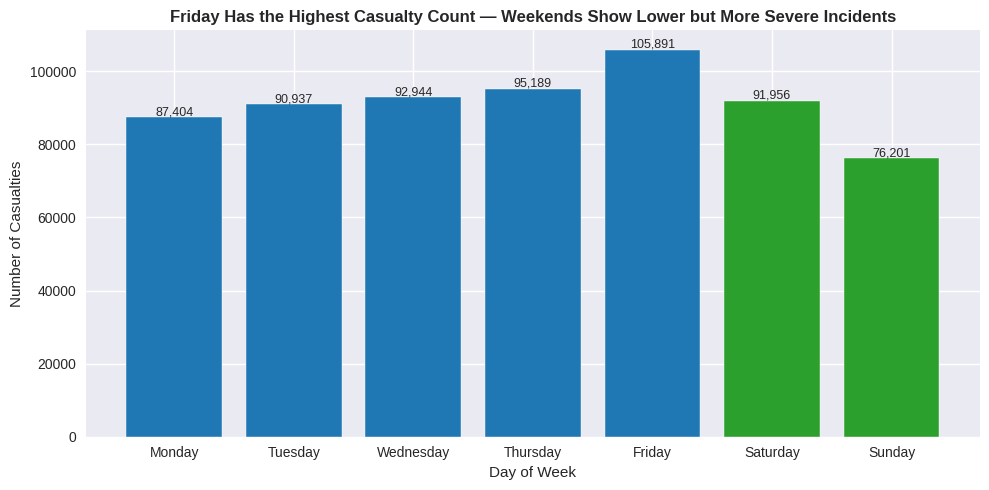

In [16]:
# ── PLOT 4: Accidents by Day of Week ────────────────────────────────────────
day_map = {1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday',
           5: 'Thursday', 6: 'Friday', 7: 'Saturday'}
df['day_name'] = df['day_of_week'].map(day_map)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_name').size().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#2ca02c' if d in ['Saturday','Sunday'] else '#1f77b4' for d in day_order]
bars = ax.bar(day_order, daily.values, color=colours, edgecolor='white')
for bar, val in zip(bars, daily.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontsize=9)
ax.set_title('Friday Has the Highest Casualty Count — Weekends Show Lower but More Severe Incidents',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Casualties')
plt.tight_layout()
plt.savefig('plot4_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

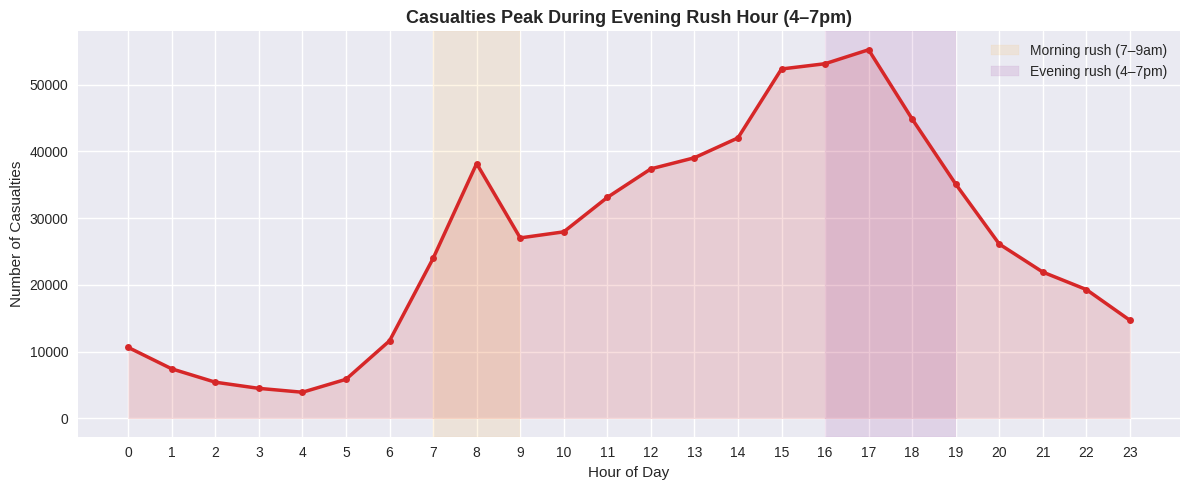

In [17]:
# ── PLOT 5: Hour of Day ──────────────────────────────────────────────────────
df['hour'] = pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.hour
hourly = df.groupby('hour').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly.index, hourly.values, marker='o', linewidth=2.5,
        color='#d62728', markersize=5)
ax.fill_between(hourly.index, hourly.values, alpha=0.15, color='#d62728')
ax.axvspan(7, 9, alpha=0.1, color='orange', label='Morning rush (7–9am)')
ax.axvspan(16, 19, alpha=0.1, color='purple', label='Evening rush (4–7pm)')
ax.set_title('Casualties Peak During Evening Rush Hour (4–7pm)', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Casualties')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('plot5_hour_of_day.png', dpi=150, bbox_inches='tight')
plt.show()

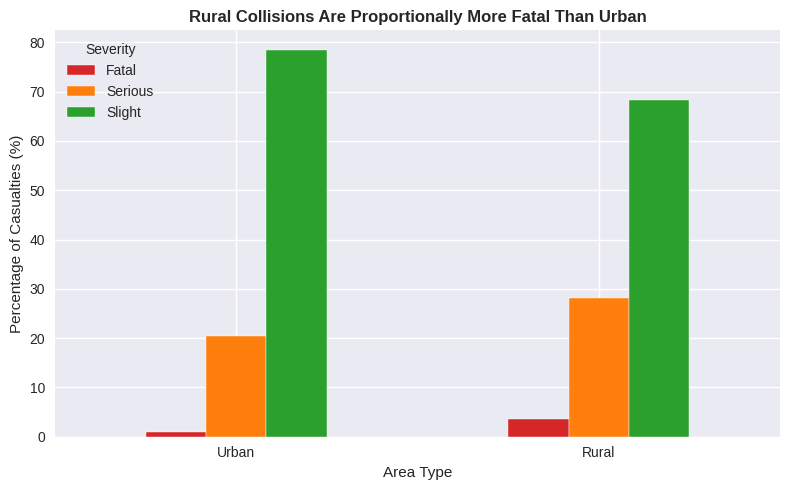

In [18]:
# ── PLOT 6: Urban vs Rural Severity ─────────────────────────────────────────
urban_map = {1: 'Urban', 2: 'Rural', 3: 'Unallocated'}
df['area_type'] = df['urban_or_rural_area'].map(urban_map)

urban_sev = df.groupby(['area_type', 'severity_label']).size().unstack(fill_value=0)
urban_sev_pct = urban_sev.div(urban_sev.sum(axis=1), axis=0) * 100
urban_sev_pct = urban_sev_pct.reindex(columns=['Fatal', 'Serious', 'Slight'])

fig, ax = plt.subplots(figsize=(8, 5))
urban_sev_pct.loc[['Urban', 'Rural']].plot(kind='bar', ax=ax,
    color=['#d62728', '#ff7f0e', '#2ca02c'], edgecolor='white')
ax.set_title('Rural Collisions Are Proportionally More Fatal Than Urban',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Area Type')
ax.set_ylabel('Percentage of Casualties (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Severity')
plt.tight_layout()
plt.savefig('plot6_urban_rural.png', dpi=150, bbox_inches='tight')
plt.show()

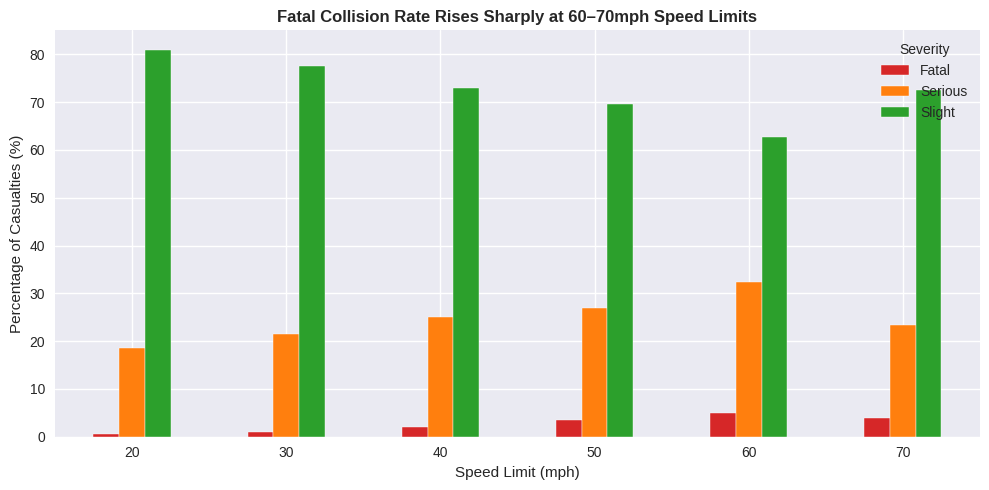

In [19]:
# ── PLOT 7: Speed Limit vs Severity ─────────────────────────────────────────
speed_sev = df.groupby(['speed_limit', 'severity_label']).size().unstack(fill_value=0)
speed_sev_pct = speed_sev.div(speed_sev.sum(axis=1), axis=0) * 100
speed_sev_pct = speed_sev_pct.reindex(columns=['Fatal', 'Serious', 'Slight'])
# Keep common speed limits only
common_speeds = [20, 30, 40, 50, 60, 70]
speed_sev_pct = speed_sev_pct.loc[speed_sev_pct.index.isin(common_speeds)]

fig, ax = plt.subplots(figsize=(10, 5))
speed_sev_pct.plot(kind='bar', ax=ax,
    color=['#d62728', '#ff7f0e', '#2ca02c'], edgecolor='white')
ax.set_title('Fatal Collision Rate Rises Sharply at 60–70mph Speed Limits',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Speed Limit (mph)')
ax.set_ylabel('Percentage of Casualties (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Severity')
plt.tight_layout()
plt.savefig('plot7_speed_limit.png', dpi=150, bbox_inches='tight')
plt.show()

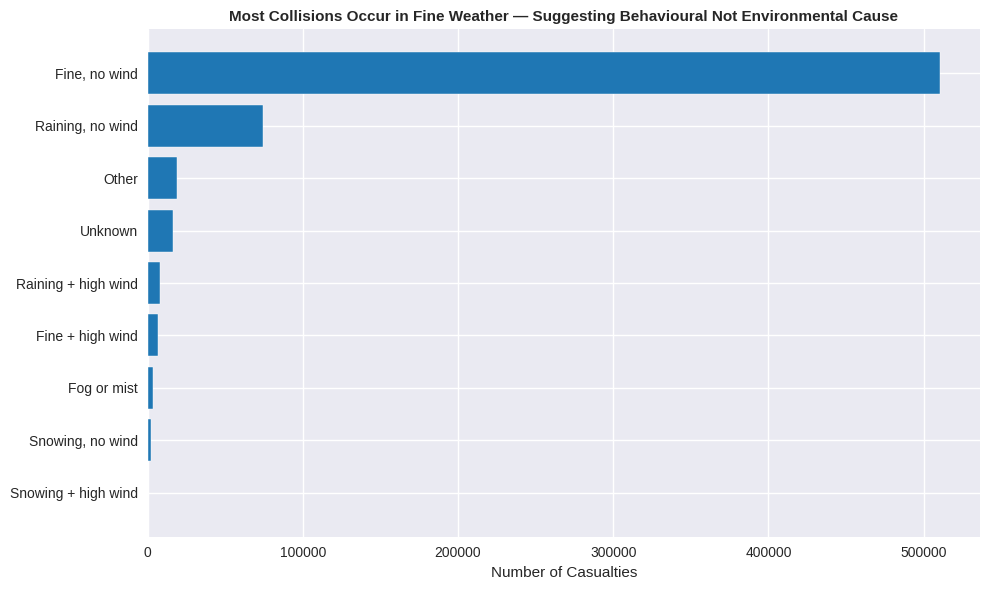

In [20]:
# ── PLOT 8: Weather Conditions ───────────────────────────────────────────────
weather_map = {
    1: 'Fine, no wind', 2: 'Raining, no wind', 3: 'Snowing, no wind',
    4: 'Fine + high wind', 5: 'Raining + high wind', 6: 'Snowing + high wind',
    7: 'Fog or mist', 8: 'Other', 9: 'Unknown'
}
df['weather'] = df['weather_conditions'].map(weather_map)
weather_counts = df.groupby('weather').size().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(weather_counts.index, weather_counts.values, color='#1f77b4', edgecolor='white')
ax.set_title('Most Collisions Occur in Fine Weather — Suggesting Behavioural Not Environmental Cause',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Number of Casualties')
plt.tight_layout()
plt.savefig('plot8_weather.png', dpi=150, bbox_inches='tight')
plt.show()

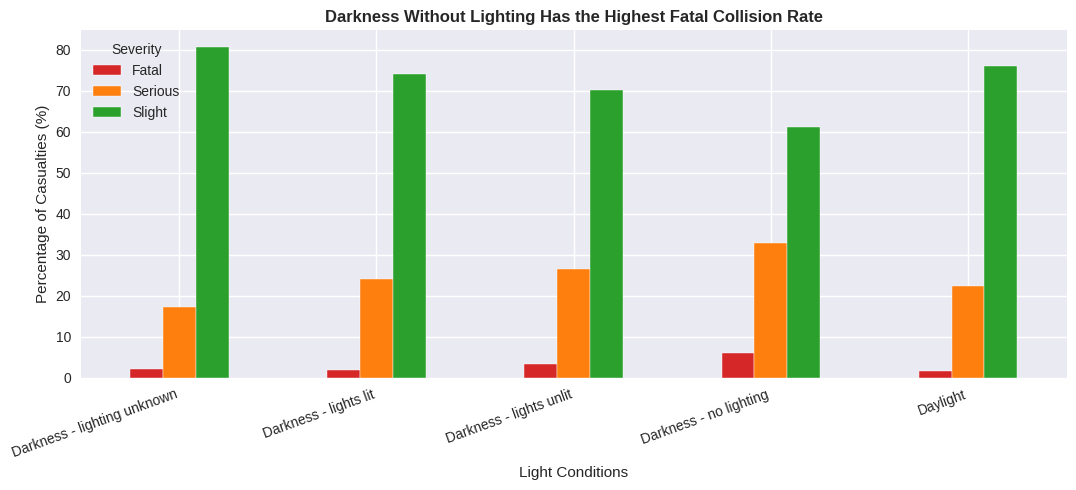

In [21]:
# ── PLOT 9: Light Conditions ─────────────────────────────────────────────────
light_map = {
    1: 'Daylight', 4: 'Darkness - lights lit', 5: 'Darkness - lights unlit',
    6: 'Darkness - no lighting', 7: 'Darkness - lighting unknown'
}
df['light'] = df['light_conditions'].map(light_map)
light_sev = df.groupby(['light', 'severity_label']).size().unstack(fill_value=0)
light_sev_pct = light_sev.div(light_sev.sum(axis=1), axis=0) * 100
light_sev_pct = light_sev_pct.reindex(columns=['Fatal', 'Serious', 'Slight']).dropna()

fig, ax = plt.subplots(figsize=(11, 5))
light_sev_pct.plot(kind='bar', ax=ax,
    color=['#d62728', '#ff7f0e', '#2ca02c'], edgecolor='white')
ax.set_title('Darkness Without Lighting Has the Highest Fatal Collision Rate',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Light Conditions')
ax.set_ylabel('Percentage of Casualties (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Severity')
plt.tight_layout()
plt.savefig('plot9_light_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

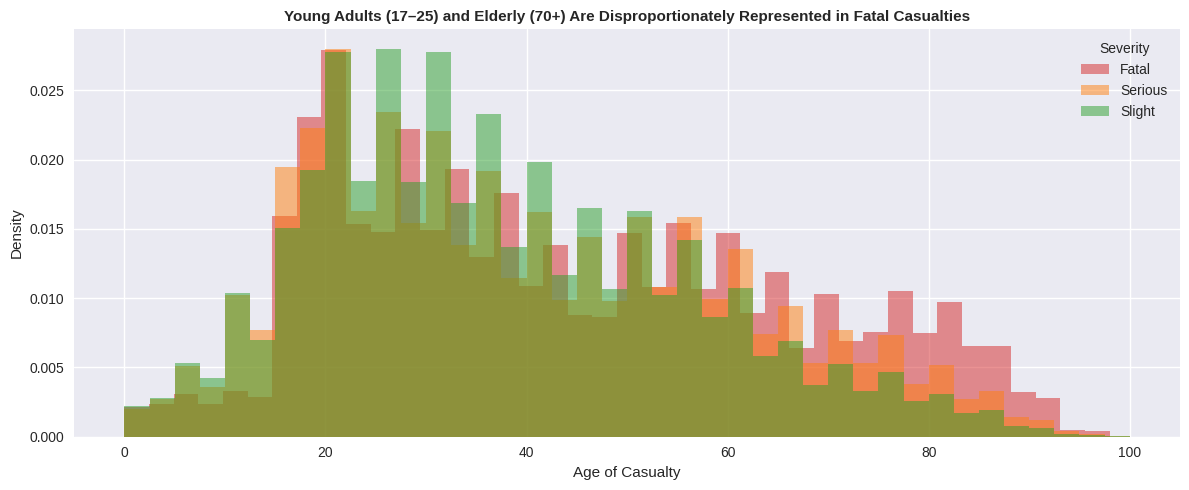

In [22]:
# ── PLOT 10: Age of Casualty Distribution ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for label, colour in zip(['Fatal', 'Serious', 'Slight'],
                          ['#d62728', '#ff7f0e', '#2ca02c']):
    subset = df[df['severity_label'] == label]['age_of_casualty']
    subset = subset[(subset >= 0) & (subset <= 100)]
    ax.hist(subset, bins=40, alpha=0.5, label=label, color=colour, density=True)
ax.set_title('Young Adults (17–25) and Elderly (70+) Are Disproportionately Represented in Fatal Casualties',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Age of Casualty')
ax.set_ylabel('Density')
ax.legend(title='Severity')
plt.tight_layout()
plt.savefig('plot10_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── STATISTICAL TEST: Chi-square — Urban/Rural vs Severity ───────────────────
from scipy.stats import chi2_contingency

contingency = df[df['area_type'].isin(['Urban', 'Rural'])].groupby(
    ['area_type', 'severity_label']).size().unstack(fill_value=0)
contingency = contingency.reindex(columns=['Fatal', 'Serious', 'Slight'])

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square test: Urban vs Rural × Severity")
print(f"χ² = {chi2:.2f}, p-value = {p:.2e}, degrees of freedom = {dof}")
if p < 0.05:
    print("✅ Result is statistically significant (p < 0.05)")
    print("→ Area type (urban/rural) has a significant association with collision severity")

Chi-square test: Urban vs Rural × Severity
χ² = 11148.48, p-value = 0.00e+00, degrees of freedom = 2
✅ Result is statistically significant (p < 0.05)
→ Area type (urban/rural) has a significant association with collision severity


In [24]:
# ── SUMMARY: Key Findings ─────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║           UK ROAD SAFETY EDA — KEY FINDINGS (2020–2024)         ║
╠══════════════════════════════════════════════════════════════════╣
║ 1. Rural collisions are proportionally more fatal than urban     ║
║    despite lower volume — risk per collision is higher rurally   ║
║ 2. Evening rush hour (4–7pm) accounts for peak casualty volume   ║
║ 3. Fatal rate rises sharply at 60–70mph speed limits             ║
║ 4. Most collisions occur in fine weather — behavioural cause     ║
║ 5. Young adults (17–25) over-represented in fatal casualties     ║
║ Chi-square confirms urban/rural × severity association (p<0.05)  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           UK ROAD SAFETY EDA — KEY FINDINGS (2020–2024)         ║
╠══════════════════════════════════════════════════════════════════╣
║ 1. Rural collisions are proportionally more fatal than urban     ║
║    despite lower volume — risk per collision is higher rurally   ║
║ 2. Evening rush hour (4–7pm) accounts for peak casualty volume   ║
║ 3. Fatal rate rises sharply at 60–70mph speed limits             ║
║ 4. Most collisions occur in fine weather — behavioural cause     ║
║ 5. Young adults (17–25) over-represented in fatal casualties     ║
║ Chi-square confirms urban/rural × severity association (p<0.05)  ║
╚══════════════════════════════════════════════════════════════════╝

